<a href="https://colab.research.google.com/github/Amirhosseinpoor/mechat/blob/master/mechatronic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub
import kagglehub
!pip install tensorflow

In [ ]:
path = kagglehub.dataset_download("marusagar/hand-gesture-detection-system")

In [ ]:
import os
import random
from collections import defaultdict
import matplotlib.pyplot as plt

# مسیر دیتا
train = path + "/train/train"
val = path + "/val/val"

# تعریف الگوها برای هر کلاس اصلی
class_patterns = {
    "Thumbs Up": ["Thumbs Up_new", "Thumbs_Up_new"],
    "Left Swipe": ["Left Swipe_new_Left Swipe_new", "Left_Swipe_new"],
    "Right Swipe": ["Right Swipe_new", "Right_Swipe_new"],
    "Stop Gesture": ["Stop_new", "Stop Gesture_new"],
    "Thumbs Down": ["Thumbs Down_new", "Thumbs_Down_new"]
}

# شمارش فولدر و فریم‌ها
folder_counts = defaultdict(int)
frame_counts = defaultdict(int)

for folder in os.listdir(train):
    folder_path = os.path.join(train, folder)
    if os.path.isdir(folder_path):
        for main_class, patterns in class_patterns.items():
            if any(pat in folder for pat in patterns):
                folder_counts[main_class] += 1
                num_frames = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))])
                frame_counts[main_class] += num_frames
                break


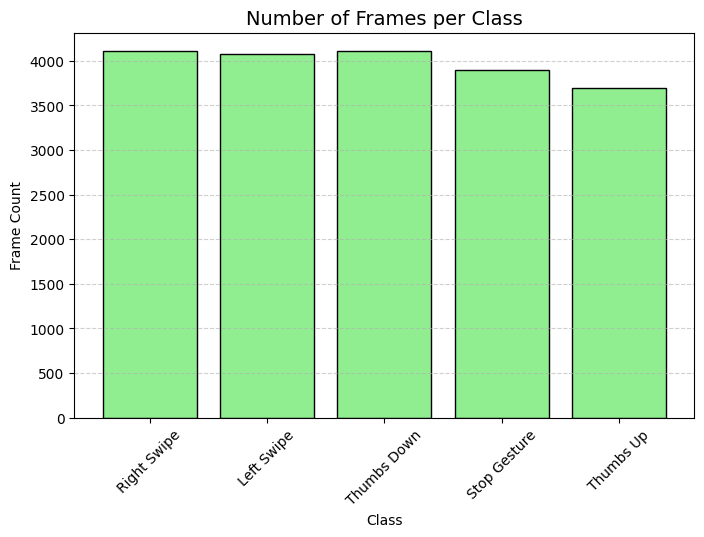

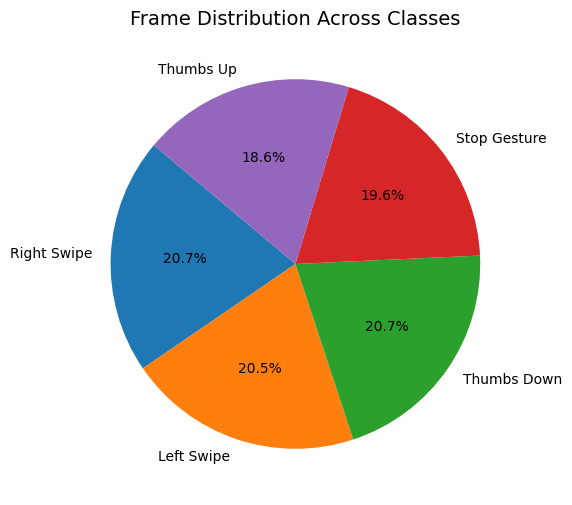

In [ ]:
# Bar Plot
plt.figure(figsize=(8,5))
plt.bar(frame_counts.keys(), frame_counts.values(), color='lightgreen', edgecolor='black')
plt.title("Number of Frames per Class", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Frame Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(frame_counts.values(), labels=frame_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title("Frame Distribution Across Classes", fontsize=14)
plt.show()


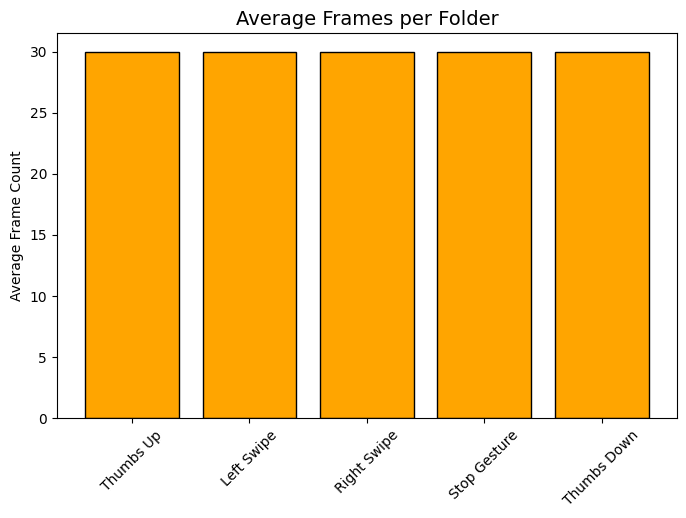

In [ ]:
avg_frames = {cls: frame_counts[cls]/folder_counts[cls] if folder_counts[cls]>0 else 0
              for cls in class_patterns.keys()}

plt.figure(figsize=(8,5))
plt.bar(avg_frames.keys(), avg_frames.values(), color='orange', edgecolor='black')
plt.title("Average Frames per Folder", fontsize=14)
plt.ylabel("Average Frame Count")
plt.xticks(rotation=45)
plt.show()


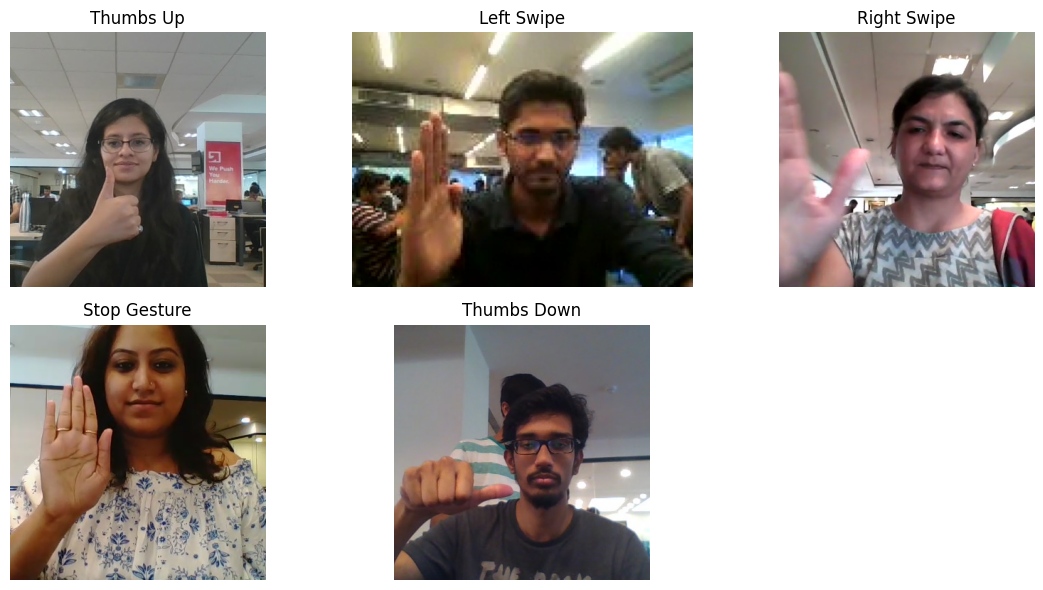

In [ ]:
plt.figure(figsize=(12, 6))
for i, cls in enumerate(class_patterns.keys()):
    folder_candidates = [f for f in os.listdir(train) if any(pat in f for pat in class_patterns[cls])]
    if folder_candidates:
        chosen_folder = random.choice(folder_candidates)
        folder_path = os.path.join(train, chosen_folder)
        img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))]
        if img_files:
            chosen_img = random.choice(img_files)
            img_path = os.path.join(folder_path, chosen_img)
            img = plt.imread(img_path)
            plt.subplot(2, 3, i+1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(cls)
plt.tight_layout()
plt.show()


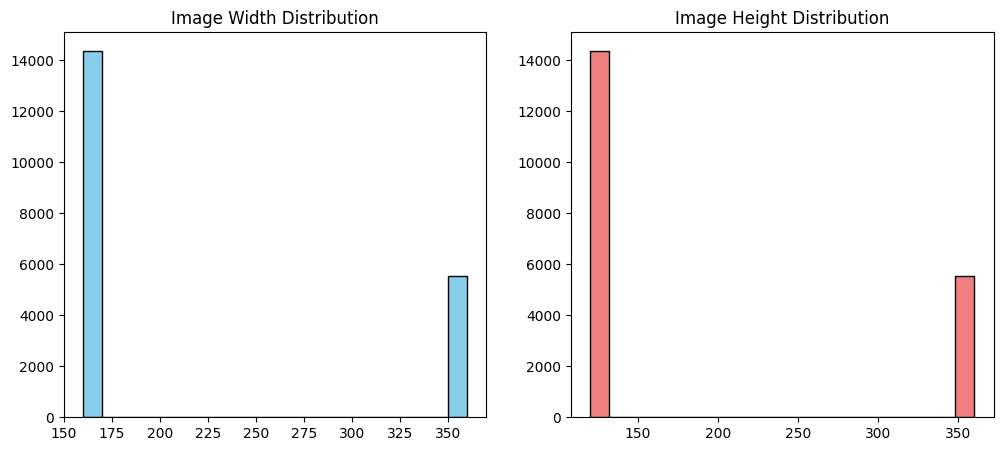

In [ ]:
img_sizes = []
for folder in os.listdir(train):
    folder_path = os.path.join(train, folder)
    if os.path.isdir(folder_path):
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.jpg', '.png')):
                img_path = os.path.join(folder_path, img_file)
                img = plt.imread(img_path)
                img_sizes.append(img.shape[:2])  # (height, width)

heights = [h for h, w in img_sizes]
widths = [w for h, w in img_sizes]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='skyblue', edgecolor='black')
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='lightcoral', edgecolor='black')
plt.title("Image Height Distribution")

plt.show()


In [ ]:
max_class = max(frame_counts, key=frame_counts.get)
min_class = min(frame_counts, key=frame_counts.get)

print(f"📊 Most frames: {max_class} ({frame_counts[max_class]})")
print(f"📉 Least frames: {min_class} ({frame_counts[min_class]})")
print(f"⚖️ Imbalance Ratio: {frame_counts[max_class] / frame_counts[min_class]:.2f}")


📊 Most frames: Right Swipe (4110)
📉 Least frames: Thumbs Up (3690)
⚖️ Imbalance Ratio: 1.11


In [ ]:
!pip install mediapipe

Mediapipe Has been Setup.
✅ Train: (663, 30, 63), Validation: (100, 30, 63)

🚀 Training LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3014 - loss: 1.5458 - val_accuracy: 0.7300 - val_loss: 1.0632
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - accuracy: 0.6902 - loss: 0.9546 - val_accuracy: 0.8100 - val_loss: 0.5143
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8505 - loss: 0.4675 - val_accuracy: 0.9400 - val_loss: 0.2374
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9030 - loss: 0.2867 - val_accuracy: 0.9400 - val_loss: 0.2419
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8739 - loss: 0.3225 - val_accuracy: 0.9400 - val_loss: 0.1812
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9303 - loss: 0.2254 - val_accuracy: 0.8800 - val_loss: 0.3192
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9136 - loss: 0.2765 - val_accuracy: 0.9400 - val_loss: 0.1628
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9547 - loss: 0.1650 - val_accuracy: 0.9500 - v

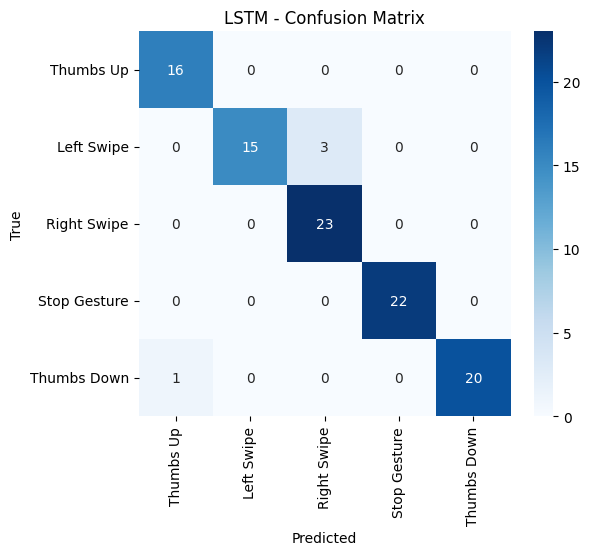

✅ LSTM best val_accuracy: 0.9800
              precision    recall  f1-score   support

   Thumbs Up       0.94      1.00      0.97        16
  Left Swipe       1.00      0.83      0.91        18
 Right Swipe       0.88      1.00      0.94        23
Stop Gesture       1.00      1.00      1.00        22
 Thumbs Down       1.00      0.95      0.98        21

    accuracy                           0.96       100
   macro avg       0.97      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100


🚀 Training GRU model...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3113 - loss: 1.5674 - val_accuracy: 0.7100 - val_loss: 1.2851
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.6179 - loss: 1.2279 - val_accuracy: 0.7500 - val_loss: 0.8393
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7342 - loss: 0.7694 - val_accuracy: 0.8800 - val_loss: 0.4754
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7821 - 

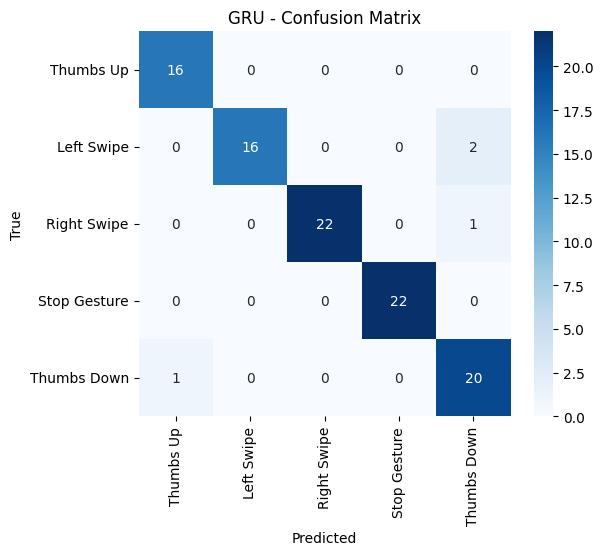

✅ GRU best val_accuracy: 0.9700
              precision    recall  f1-score   support

   Thumbs Up       0.94      1.00      0.97        16
  Left Swipe       1.00      0.89      0.94        18
 Right Swipe       1.00      0.96      0.98        23
Stop Gesture       1.00      1.00      1.00        22
 Thumbs Down       0.87      0.95      0.91        21

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100


🚀 Training RNN model...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.2074 - loss: 1.8560 - val_accuracy: 0.6100 - val_loss: 1.2896
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3703 - loss: 1.4174 - val_accuracy: 0.7800 - val_loss: 0.8826
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6425 - loss: 0.9560 - val_accuracy: 0.9000 - val_loss: 0.5146
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7685 - 

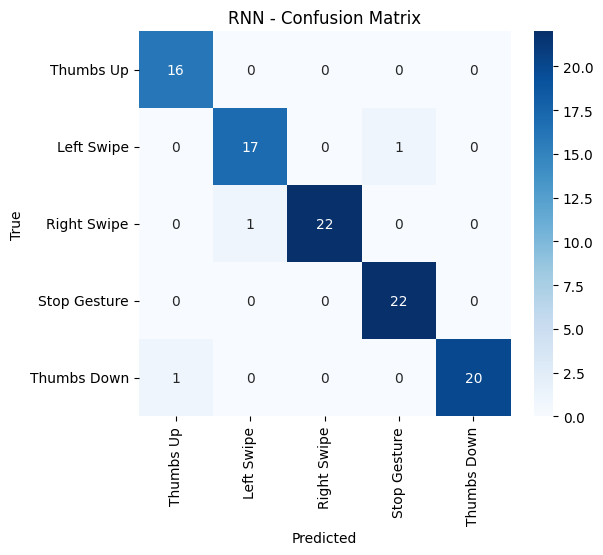

✅ RNN best val_accuracy: 0.9800
              precision    recall  f1-score   support

   Thumbs Up       0.94      1.00      0.97        16
  Left Swipe       0.94      0.94      0.94        18
 Right Swipe       1.00      0.96      0.98        23
Stop Gesture       0.96      1.00      0.98        22
 Thumbs Down       1.00      0.95      0.98        21

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100


🚀 Training MLP model...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.2558 - loss: 1.7709 - val_accuracy: 0.7100 - val_loss: 1.1116
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5505 - loss: 1.1596 - val_accuracy: 0.8600 - val_loss: 0.7445
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6882 - loss: 0.8169 - val_accuracy: 0.8900 - val_loss: 0.4447
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7611 - los

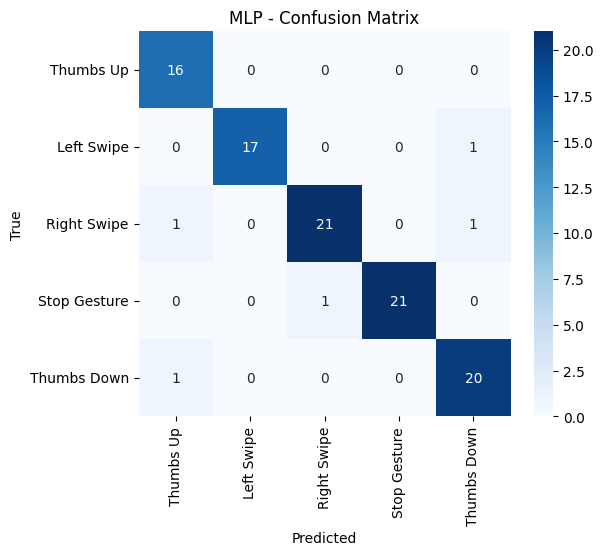

✅ MLP best val_accuracy: 0.9600
              precision    recall  f1-score   support

   Thumbs Up       0.89      1.00      0.94        16
  Left Swipe       1.00      0.94      0.97        18
 Right Swipe       0.95      0.91      0.93        23
Stop Gesture       1.00      0.95      0.98        22
 Thumbs Down       0.91      0.95      0.93        21

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



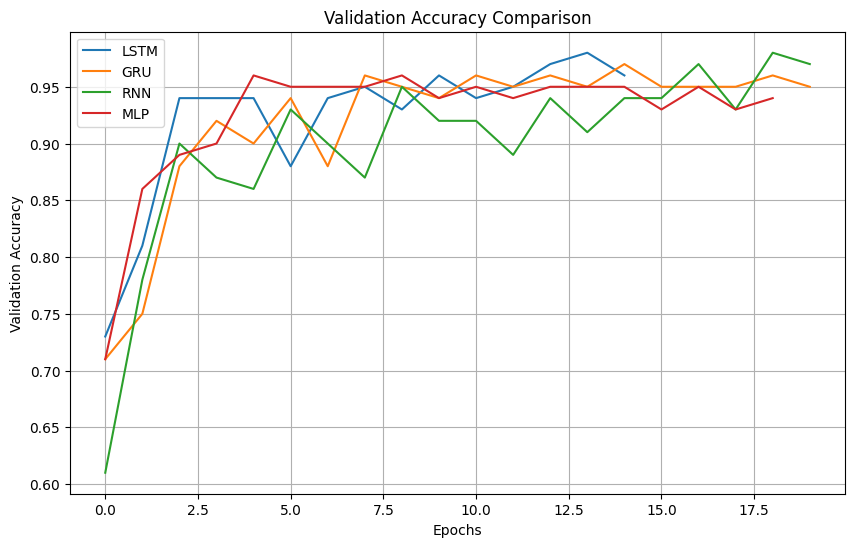


🌟 Best Model: LSTM with val_accuracy=0.9800


In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ========================
# تنظیمات
# ========================
SEQUENCE_LENGTH = 30

class_patterns = {
    "Thumbs Up": ["Thumbs Up_new", "Thumbs_Up_new"],
    "Left Swipe": ["Left Swipe_new_Left Swipe_new", "Left_Swipe_new"],
    "Right Swipe": ["Right Swipe_new", "Right_Swipe_new"],
    "Stop Gesture": ["Stop_new", "Stop Gesture_new"],
    "Thumbs Down": ["Thumbs Down_new", "Thumbs_Down_new"]
}

class_names = list(class_patterns.keys())
NUM_CLASSES = len(class_names)
class_map = {name: idx for idx, name in enumerate(class_names)}

# ========================
# MediaPipe setup
# ========================
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)
# ========================
# استخراج فیچرها با MediaPipe
# ========================
def extract_landmarks(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)
    if results.multi_hand_landmarks:
        lm_list = []
        hand_landmarks = results.multi_hand_landmarks[0]
        for lm in hand_landmarks.landmark:
            lm_list.extend([lm.x, lm.y, lm.z])
        return lm_list
    else:
        return [0]*63  # اگر دست پیدا نشد

def load_dataset(base_path):
    sequences, labels = [], []
    for gesture_name, patterns in class_patterns.items():
        gesture_folders = [f for f in os.listdir(base_path) if any(p in f for p in patterns)]
        for folder_name in gesture_folders:
            folder_path = os.path.join(base_path, folder_name)
            frames = sorted(os.listdir(folder_path))
            landmarks_seq = []
            for f in frames:
                img_path = os.path.join(folder_path, f)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                landmarks = extract_landmarks(img)
                landmarks_seq.append(landmarks)
            for i in range(len(landmarks_seq) - SEQUENCE_LENGTH + 1):
                seq = landmarks_seq[i:i+SEQUENCE_LENGTH]
                sequences.append(seq)
                labels.append(class_map[gesture_name])
    return np.array(sequences), np.array(labels)
print('Mediapipe Has been Setup.')
# ========================
# لود دیتاست (train / val)
# ========================
X_train, y_train = load_dataset(train)
X_val, y_val = load_dataset(val)

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)

print(f"✅ Train: {X_train.shape}, Validation: {X_val.shape}")

# ========================
# تعریف مدل‌ها
# ========================
def build_lstm():
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 63), unroll=True))
    model.add(Dropout(0.5))
    model.add(LSTM(64, unroll=True))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    return model

def build_gru():
    model = Sequential()
    model.add(GRU(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 63), unroll=True))
    model.add(Dropout(0.5))
    model.add(GRU(64, unroll=True))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    return model


def build_rnn():
    model = Sequential()
    model.add(SimpleRNN(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 63)))
    model.add(Dropout(0.5))
    model.add(SimpleRNN(64))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    return model

def build_mlp():
    model = Sequential()
    model.add(Flatten(input_shape=(SEQUENCE_LENGTH, 63)))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    return model

# ========================
# ترین و ارزیابی مدل‌ها
# ========================
models = {
    "LSTM": build_lstm(),
    "GRU": build_gru(),
    "RNN": build_rnn(),
    "MLP": build_mlp()
}

histories = {}
reports = {}
val_accuracies = {}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for name, model in models.items():
    print(f"\n🚀 Training {name} model...")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=20,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )
    histories[name] = history

    # Best validation accuracy
    val_acc = max(history.history['val_accuracy'])
    val_accuracies[name] = val_acc

    # Predictions
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Classification report
    report = classification_report(y_val, y_pred_classes, target_names=class_names, output_dict=True)
    reports[name] = report

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.show()

    print(f"✅ {name} best val_accuracy: {val_acc:.4f}")
    print(classification_report(y_val, y_pred_classes, target_names=class_names))

# ========================
# مقایسه Validation Accuracy
# ========================
plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f"{name}")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ========================
# انتخاب بهترین مدل
# ========================
best_model_name = max(val_accuracies, key=val_accuracies.get)
print(f"\n🌟 Best Model: {best_model_name} with val_accuracy={val_accuracies[best_model_name]:.4f}")


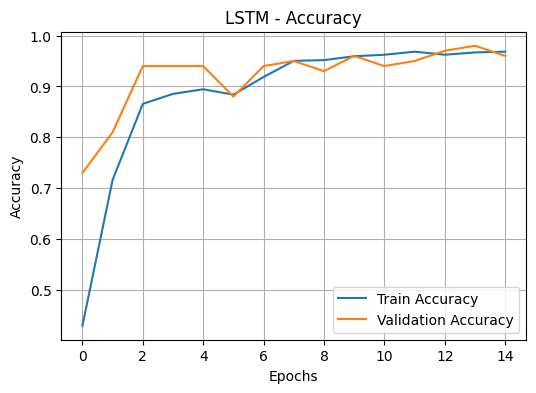

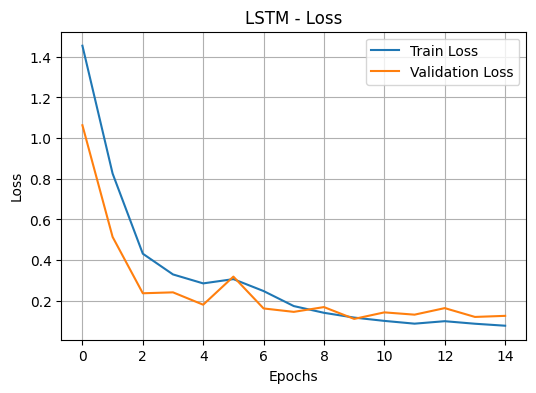

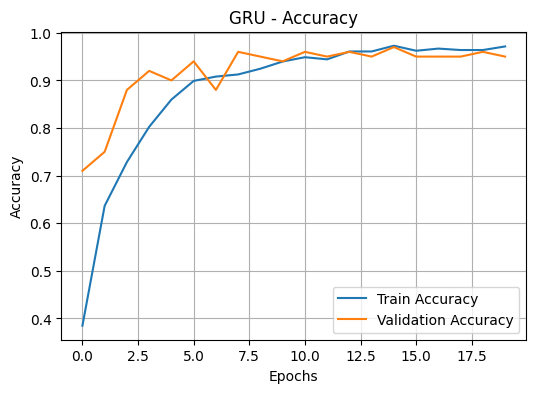

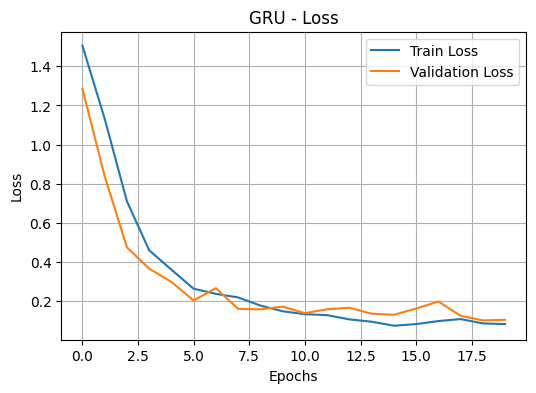

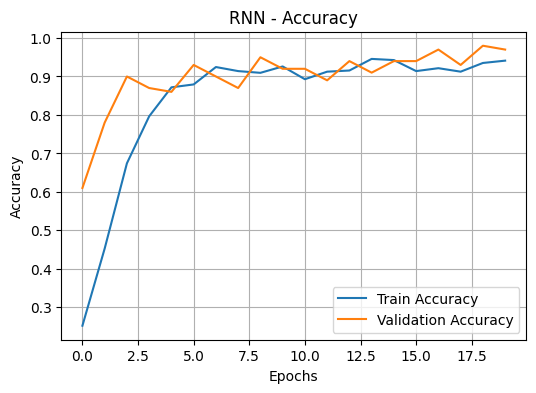

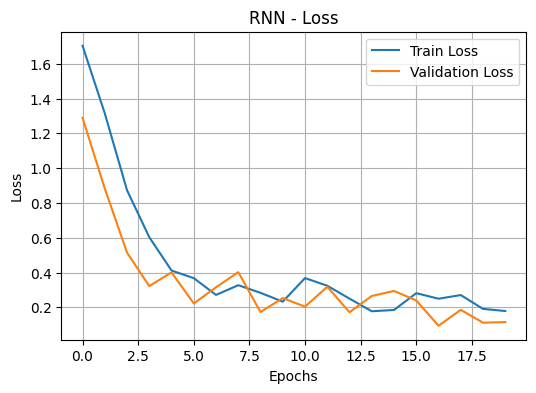

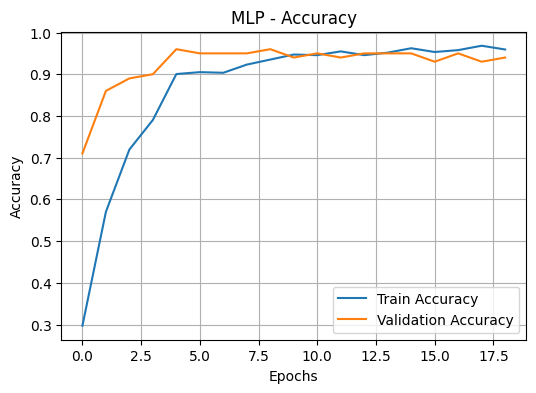

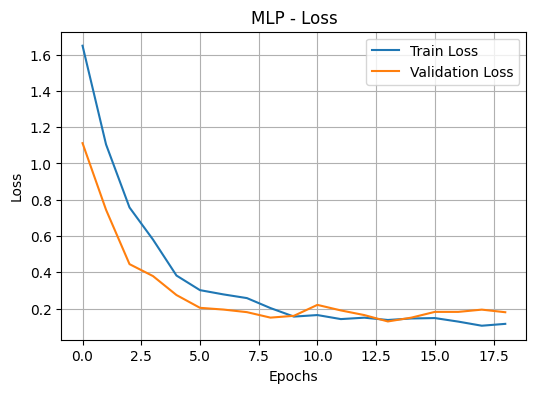

In [ ]:
for name, history in histories.items():
    # دقت
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"{name} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # خطا
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{name} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
best_model_name = max(val_accuracies, key=val_accuracies.get)
best_model = models[best_model_name]
print(best_model_name)
# ذخیره
best_model.save(f"{best_model_name}_best_model2.h5")
print(f"✅ Saved best model: {best_model_name}_best_model2.h5")


LSTM
✅ Saved best model: LSTM_best_model2.h5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# انتقال فایل
!cp {best_model_name}_best_model2.h5 "/content/drive/MyDrive/"
print("✅ Model copied to Google Drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

tflite_path = f"{best_model_name}_best_model2.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ Converted and saved best model as {tflite_path}")

Saved artifact at '/tmp/tmpu_0uwpgs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 63), dtype=tf.float32, name='keras_tensor_197')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140433975738192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433975738000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433975737616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978508688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978508496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978509648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978509456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978508880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978510416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140433978507536: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Converted and s

In [ ]:
!cp {best_model_name}_best_model2.tflite "/content/drive/MyDrive/"
print("✅ Model copied to Google Drive")

✅ Model copied to Google Drive
